In [ ]:
%pip install seaborn -q
%pip install pandas -q
%pip install statsmodels -q
%pip install scikit-learn -q
%pip install scipy -q

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as skl
from math import ceil
from statsmodels.stats.weightstats import ztest

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [199]:
# Pull data in for testing
hdf = pd.read_json('nsmes1988.json')
dhdf = pd.read_csv('nmses1988_dirty_tabs_replaced.csv')
hdf = hdf.drop(hdf.columns[0], axis=1)
print(hdf.keys())
print(len(dhdf))
print(dhdf.keys())



Index(['num_physician_office_visits', 'num_non_physician_office_visits',
       'num_outpatient_physician_office_visits',
       'num_outpatient_non_physician_office_visits', 'num_emergency_visits',
       'num_hospital_stays', 'self_reported_health_factor',
       'num_chronic_conds', 'daily_acty_limit_factor', 'region', 'age',
       'gender', 'married', 'num_school_years', 'income', 'employed',
       'has_priv_insurance', 'has_medicaid_coverage'],
      dtype='object')
4406
Index(['visits', 'nvisits', 'ovisits', 'novisits', 'emergency', 'hospital',
       'health', 'chronic', 'adl', 'region', 'age', 'gender', 'married',
       'school', 'income', 'employed', 'insurance', 'medicaid'],
      dtype='object')


In [ ]:
def scan_for_bad_data_cells(data: pd.DataFrame):
    print('Scanning dataframe for missing or bad data')
    # Compile a regex pattern for known bad strings
    # These can be ignored if values are accepted for that field
    regex_pattern = r'nan|unk|none|na|n/a|unknown|0|^$'
    # Create zero filled copy of passed df
    print(data.describe(include='all'))
    print(data.info(verbose=True, show_counts=True))
    counter_df = pd.DataFrame(0, index=np.arange(len(data)), columns=data.keys())
    for col in data.keys():
        if data[col].dtype == 'object':
            str_results = data[col].str.contains(regex_pattern, case=False, regex=True)
        else:
            str_results = data[col].isna() | data[col].isnull()
        results = data[col].isna() | data[col].isnull()
        full_results = str_results | results
        counter_df[col] = full_results.astype('Float32')
    print('Printout of scan results')
    counter_df.insert(0,'num_of_invalid_vals', counter_df.sum(axis=1, skipna=True, numeric_only=True))
    print(f'Invalid entries per index: {counter_df['num_of_invalid_vals']}')
    counter_df.set_index('num_of_invalid_vals', inplace=True)
    print(counter_df.tail(10).to_string())
    for col in counter_df:
        print(f'Number of invalid values in column {col}: {counter_df[col].sum()}')
    

    
def plot_all_data(data: pd.DataFrame, name: str='') -> None:
    print('Plotting all columns as hist and box plots')
    print(data.describe(include='all'))
    print(data.info(verbose=True, show_counts=True))
    col_len = len(data.keys())
    ax_rows = 2 * ceil(col_len / 3)
    print(f'Column Len = {col_len}')
    print(f'Axes Rows Amount = {ax_rows}')
    ax_cols = 3 if col_len >= 3 else col_len
    fig, axs = plt.subplots(ax_rows, ax_cols, figsize=[12, 8*ceil(ax_rows/2)])
    col_counter = 0
    row_counter = 0
    for col in data.keys():
        sns.histplot(data=data, x=col, ax=axs[row_counter,col_counter])
        
        sns.boxplot(data=data, x=col, ax=axs[row_counter+1,col_counter])
        col_counter += 1
        if col_counter > 2:
            col_counter = 0
            row_counter += 2
    fig.suptitle(name)

from scipy.stats import ttest_1samp
from pandas.api.types import is_numeric_dtype
def simple_ttest_all_data_columns(data: pd.DataFrame, alpha:float=0.05, samples:int=30):
    print('Starting T-tests...')
    for col in data:
        if not is_numeric_dtype(data[col]):
            print(f'Skipping {col} as dtype is not numeric')
            continue
        col_mean = data[col].mean()
        print(f'mean for {col}: {col_mean}')
        t_statistic, p_val = ttest_1samp(data[col], samples)
        print(f'p_value for {col}: {p_val}')
        if p_val < alpha:
            print(f'Reject null hypothesis for {col}')
        else:
            print(f'Fail to reject null hypothesis for {col}')
    print('')

def ztest_all_data_columns(data: pd.DataFrame, alpha:float=0.05, samples:int=50):
    print('Starting Z-tests')
    for col in data:
        if not is_numeric_dtype(data[col]):
            print(f'Skipping {col} as dtype is not numeric')
            continue
        col_mean = data[col].mean()
        print(f'mean for {col}: {col_mean}')
        
        ztest_score, p_val = ztest(data[col].sample(samples), value=col_mean, alternative='larger')
        print(f'p_value for {col}: {p_val}')
        if p_val < alpha:
            print(f'Reject null hypothesis for {col}')
        else:
            print(f'Fail to reject null hypothesis for {col}')
    print('')

def plot_features_vs_col(full_df, col_name):
    df = full_df.copy().drop(columns=[col_name])
    y = full_df[col_name]
    height = ceil(len(df.columns)/3)
    sub_fig, axs = plt.subplots(height,3, sharey=True, figsize=(20,6*height), constrained_layout=True)
    counter = 0
    lkws = {'color':'black', 'linestyle':'--', 'alpha':0.3}
    cbax = []
    for ax, col in zip(axs.flatten(), df.columns):
        df_x = df[col]
        xy = np.vstack([df_x, y])
        dens = gaussian_kde(xy)(xy)
        g = sns.regplot(x=df_x,y=y,ci=False, ax=ax, line_kws=lkws, label='Trend Line')
        g.set(ylim=(0,None))
        plot_scat = ax.scatter(df_x, y, c=dens, cmap='plasma')
        ax.set_xlabel(col)
        ax.set_ylabel('')
        if counter and counter % 3 != 0:
            ax.tick_params(axis='y', which='both', left=False, right=False)
        if counter and (counter+1) % 3 == 0:
            cbax.append(ax)
        counter += 1
        
    sub_fig.suptitle('Features × Total Spent', x=0.47, ha='center')
    sub_fig.supylabel('Total Spent')
    # axs[1].legend(loc='upper left')
    for ax in cbax:
        plt.colorbar(plot_scat, ax=ax, pad=0.01, label='KDE')
    plt.show()

In [213]:
print('clean data testing')
simple_ttest_all_data_columns(data=hdf)

ztest_all_data_columns(data=hdf, samples=300)

print('dirty data testing')
simple_ttest_all_data_columns(data=dhdf)

ztest_all_data_columns(data=dhdf, samples=300)

clean data testing
Starting T-tests...
mean for num_physician_office_visits: 5.774398547435315
p_value for num_physician_office_visits: 0.0
Reject null hypothesis for num_physician_office_visits
mean for num_non_physician_office_visits: 1.61802088061734
p_value for num_non_physician_office_visits: 0.0
Reject null hypothesis for num_non_physician_office_visits
mean for num_outpatient_physician_office_visits: 0.7507943713118475
p_value for num_outpatient_physician_office_visits: 0.0
Reject null hypothesis for num_outpatient_physician_office_visits
mean for num_outpatient_non_physician_office_visits: 0.5360871538810713
p_value for num_outpatient_non_physician_office_visits: 0.0
Reject null hypothesis for num_outpatient_non_physician_office_visits
mean for num_emergency_visits: 0.2635043123014072
p_value for num_emergency_visits: 0.0
Reject null hypothesis for num_emergency_visits
mean for num_hospital_stays: 0.2959600544711757
p_value for num_hospital_stays: 0.0
Reject null hypothesis for

In [214]:
scan_for_bad_data_cells(dhdf)

Scanning dataframe for missing or bad data
             visits      nvisits      ovisits     novisits    emergency  \
count   4186.000000  4186.000000  4186.000000  4186.000000  4186.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN   
mean       6.006928     1.615862     0.728141     0.550406     0.262303   
std        7.361932     5.308146     3.594853     4.120928     0.694748   
min       -2.000000    -1.000000    -1.000000    -1.000000     0.000000   
25%        1.000000     0.000000     0.000000     0.000000     0.000000   
50%        4.000000     0.000000     0.000000     0.000000     0.000000   
75%        8.000000     1.000000     0.000000     0.000000     0.000000   
max       94.000000   103.000000   139.000000   162.000000    12.000000   

           hospital   health      chronic     adl region

Plotting all columns as hist and box plots
        num_physician_office_visits  num_non_physician_office_visits  \
count                   4406.000000                      4406.000000   
unique                          NaN                              NaN   
top                             NaN                              NaN   
freq                            NaN                              NaN   
mean                       5.774399                         1.618021   
std                        6.759225                         5.317056   
min                        0.000000                         0.000000   
25%                        1.000000                         0.000000   
50%                        4.000000                         0.000000   
75%                        8.000000                         1.000000   
max                       89.000000                       104.000000   

        num_outpatient_physician_office_visits  \
count                              4406.00

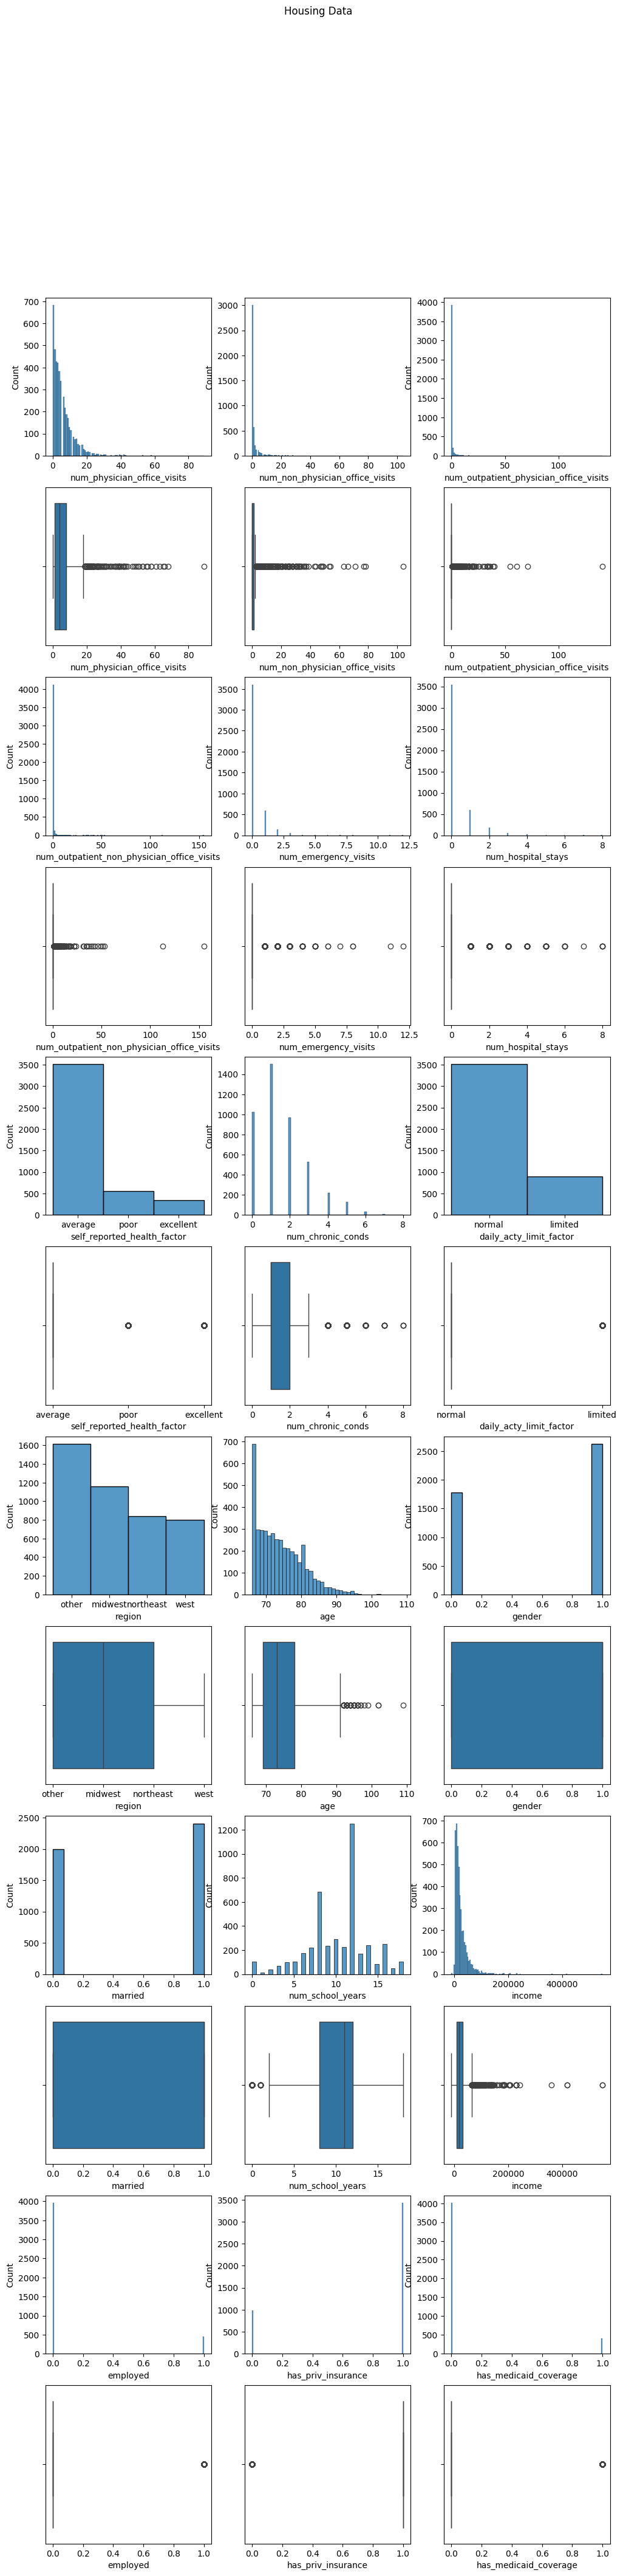

In [215]:
plot_all_data(hdf, 'Housing Data')
